# Avance 5 - Modelos de ensamble

El objetivo de esta libreta es construir y comparar **modelos de ensamble** para la detección temprana de eventos anómalos en datos de vibración de motores acoplados a bombas centrífugas. Se retoma el trabajo del avance anterior: el archivo `baseline_anomalias.csv` aporta las características construidas, la división temporal `train`/`test` y la etiqueta proxy `proxy_anomaly`, mientras que `vibracion.csv` conserva la señal cruda usada por el modelo no supervisado.

Se aplican estrategias de ensamble **homogéneas** (bagging y boosting sobre un mismo tipo de estimador) y **heterogéneas** (voting y stacking combinando algoritmos distintos). Para el stacking se emplean los **mejores modelos individuales de la fase previa (Avance 4)** como estimadores base. Finalmente, se sintetizan todos los resultados en una tabla comparativa y se elige el modelo final alineado con las necesidades del negocio.

La etiqueta proxy representa eventos extremos de vibración, no fallas reales confirmadas. Por ello, los resultados deben interpretarse como una comparación técnica; una siguiente etapa debería reemplazar esta etiqueta con registros reales de mantenimiento o falla.

## Requisitos cubiertos

- Construir una variedad de modelos de ensamble (homogéneos y heterogéneos).
- Incluir optimización de hiperparámetros para los modelos de ensamble más relevantes.
- Emplear estrategias de stacking/blending usando los mejores modelos individuales del Avance 4.
- Sintetizar los resultados en una tabla comparativa que incluya a los modelos individuales de la fase previa, ordenada por la métrica principal y con métricas adicionales y tiempos de entrenamiento.
- Elegir el modelo final alineado con los objetivos del negocio.
- Generar gráficos significativos del modelo seleccionado con su interpretación.

In [1]:
from pathlib import Path
from time import perf_counter
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

from sklearn.ensemble import (
    AdaBoostClassifier,
    BaggingClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    StackingClassifier,
    VotingClassifier,
)

RANDOM_STATE = 42
PRIMARY_METRIC = "f1_test"
PROJECT_DIR = Path.cwd()
DATA_PATH = PROJECT_DIR / "baseline_anomalias.csv"
RAW_DATA_PATH = PROJECT_DIR / "vibracion.csv"

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning)
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", "{:.4f}".format)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

print("Ambiente listo")
print(f"Directorio de trabajo: {PROJECT_DIR}")
print(f"Baseline supervisado: {DATA_PATH.name} | existe: {DATA_PATH.exists()}")
print(f"Senal cruda (autoencoder): {RAW_DATA_PATH.name} | existe: {RAW_DATA_PATH.exists()}")

Ambiente listo
Directorio de trabajo: /Users/leonardo/Documents/ProyectoIntegrador/ProyectoIntegradorMNA/Avance5.58
Baseline supervisado: baseline_anomalias.csv | existe: True
Senal cruda (autoencoder): vibracion.csv | existe: True


## 1. Carga de datos

Se usa `baseline_anomalias.csv` para mantener consistencia con la fase previa. La libreta valida que existan la etiqueta proxy, la columna de división temporal y las características esperadas. Estas mismas características alimentan tanto a los modelos individuales como a los ensambles supervisados.

In [2]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        "No se encontro baseline_anomalias.csv. Copia el archivo generado en el Avance 3/4 a esta carpeta."
    )

df = pd.read_csv(DATA_PATH)
df["timesTamp"] = pd.to_datetime(df["timesTamp"])

required_columns = ["timesTamp", "parameterName", "sensorId", "proxy_anomaly", "split"]
missing_required = sorted(set(required_columns) - set(df.columns))
if missing_required:
    raise ValueError(f"Faltan columnas requeridas: {missing_required}")

FEATURE_COLUMNS = [
    "RMSVelocityH",
    "RMSVelocityV",
    "RMSVelocityA",
    "energy",
    "rms_magnitude",
    "max_rms",
    "RMSVelocityH_rolling_mean_5",
    "RMSVelocityV_rolling_mean_5",
    "RMSVelocityA_rolling_mean_5",
    "energy_rolling_mean_5",
    "RMSVelocityH_rolling_std_5",
    "RMSVelocityV_rolling_std_5",
    "RMSVelocityA_rolling_std_5",
    "energy_rolling_std_5",
    "RMSVelocityH_diff_abs",
    "RMSVelocityV_diff_abs",
    "RMSVelocityA_diff_abs",
    "energy_diff_abs",
    "hour",
    "day_of_week",
]

missing_features = sorted(set(FEATURE_COLUMNS) - set(df.columns))
if missing_features:
    raise ValueError(f"Faltan caracteristicas requeridas: {missing_features}")

df = df.sort_values(["timesTamp", "parameterName", "sensorId"]).reset_index(drop=True)
df["proxy_anomaly"] = df["proxy_anomaly"].astype(bool)

print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
print("Rango temporal:")
print(df["timesTamp"].min(), "->", df["timesTamp"].max())
print("\nDistribucion train/test:")
print(df["split"].value_counts())
print("\nTasa de eventos proxy por split:")
print(df.groupby("split")["proxy_anomaly"].mean())

df.head()

Filas: 52,548
Columnas: 29
Rango temporal:
2025-01-01 02:00:00 -> 2025-12-31 23:30:00

Distribucion train/test:
split
train    36783
test     15765
Name: count, dtype: int64

Tasa de eventos proxy por split:
split
test    0.0446
train   0.0010
Name: proxy_anomaly, dtype: float64


,timesTamp,parameterName,sensorId,RMSVelocityH,RMSVelocityV,RMSVelocityA,energy,rms_magnitude,max_rms,proxy_anomaly,split,statistical_anomaly,if_anomaly,if_anomaly_bool,if_anomaly_score,RMSVelocityH_rolling_mean_5,RMSVelocityV_rolling_mean_5,RMSVelocityA_rolling_mean_5,energy_rolling_mean_5,RMSVelocityH_rolling_std_5,RMSVelocityV_rolling_std_5,RMSVelocityA_rolling_std_5,energy_rolling_std_5,RMSVelocityH_diff_abs,RMSVelocityV_diff_abs,RMSVelocityA_diff_abs,energy_diff_abs,hour,day_of_week
0,2025-01-01 02:00:00,Pump_1,189310001,0.3020,0.2560,0.3570,0.2842,0.5331,0.3570,False,train,False,1,False,0.4837,0.3004,0.2498,0.3526,0.2770,0.0042,0.0055,0.0059,0.0047,0.0050,0.0090,0.0130,0.0106,2,2
1,2025-01-01 02:00:00,Pump_2,189310002,0.2990,0.2430,0.3450,0.2675,0.5172,0.3450,False,train,False,1,False,0.4969,0.2998,0.2468,0.3538,0.2761,0.0073,0.0045,0.0076,0.0108,0.0120,0.0070,0.0170,0.0228,2,2
2,2025-01-01 02:00:00,Pump_3,189310003,0.2930,0.2480,0.3570,0.2748,0.5242,0.3570,False,train,False,1,False,0.5007,0.2998,0.2526,0.3530,0.2784,0.0079,0.0073,0.0065,0.0088,0.0160,0.0100,0.0140,0.0049,2,2
3,2025-01-01 02:30:00,Pump_1,189310001,0.3120,0.2500,0.3490,0.2816,0.5307,0.3490,False,train,False,1,False,0.4854,0.3034,0.2488,0.3518,0.2778,0.0061,0.0048,0.0061,0.0051,0.0100,0.0060,0.0080,0.0025,2,2
4,2025-01-01 02:30:00,Pump_2,189310002,0.2970,0.2500,0.3640,0.2832,0.5322,0.3640,False,train,False,1,False,0.4998,0.2988,0.2462,0.3546,0.2757,0.0072,0.0036,0.0086,0.0105,0.0020,0.0070,0.0190,0.0157,2,2


In [3]:
X_train = df.loc[df["split"].eq("train"), FEATURE_COLUMNS].copy()
y_train = df.loc[df["split"].eq("train"), "proxy_anomaly"].astype(int).copy()

X_test = df.loc[df["split"].eq("test"), FEATURE_COLUMNS].copy()
y_test = df.loc[df["split"].eq("test"), "proxy_anomaly"].astype(int).copy()

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print("\nEventos proxy:")
print(pd.Series({"train": y_train.sum(), "test": y_test.sum()}))

if y_train.nunique() < 2 or y_test.nunique() < 2:
    raise ValueError("La etiqueta proxy necesita al menos dos clases en train y test para comparar modelos.")

X_train: (36783, 20)
X_test: (15765, 20)

Eventos proxy:
train     35
test     703
dtype: int64


## 2. Métrica principal

La clase positiva (`proxy_anomaly = True`) es minoritaria. Por esa razón, la métrica principal para ordenar modelos será **F1-score en prueba**, ya que equilibra precisión y recall. También se reportan **precision**, **recall**, **accuracy**, **balanced accuracy**, tasa de alertas, matriz de confusión resumida y **tiempo de entrenamiento**.

Mantener la misma métrica y las mismas funciones de evaluación que en el Avance 4 permite comparar de forma justa los modelos individuales, los ensambles y el modelo final en una sola tabla.

In [4]:
def classification_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "alert_rate": float(np.mean(y_pred)),
        "tp": int(tp),
        "fp": int(fp),
        "tn": int(tn),
        "fn": int(fn),
    }


def get_positive_scores(estimator, X):
    if hasattr(estimator, "decision_function"):
        return estimator.decision_function(X)
    if hasattr(estimator, "predict_proba"):
        positive_index = list(estimator.classes_).index(1)
        return estimator.predict_proba(X)[:, positive_index]
    return estimator.predict(X).astype(float)


def predict_with_threshold(estimator, X, threshold=None):
    if threshold is None:
        return estimator.predict(X).astype(int)
    scores = get_positive_scores(estimator, X)
    return (scores >= threshold).astype(int)


def evaluate_estimator(name, tipo, estimator, X_train, y_train, X_test, y_test):
    model = clone(estimator)
    start = perf_counter()
    model.fit(X_train, y_train)
    training_time = perf_counter() - start

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    train_metrics = classification_metrics(y_train, y_pred_train)
    test_metrics = classification_metrics(y_test, y_pred_test)

    row = {
        "modelo": name,
        "tipo": tipo,
        "training_time_sec": training_time,
        "f1_train": train_metrics["f1"],
        "f1_test": test_metrics["f1"],
        "precision_test": test_metrics["precision"],
        "recall_test": test_metrics["recall"],
        "accuracy_test": test_metrics["accuracy"],
        "balanced_accuracy_test": test_metrics["balanced_accuracy"],
        "alert_rate_test": test_metrics["alert_rate"],
        "tp_test": test_metrics["tp"],
        "fp_test": test_metrics["fp"],
        "tn_test": test_metrics["tn"],
        "fn_test": test_metrics["fn"],
        "f1_gap_train_test": train_metrics["f1"] - test_metrics["f1"],
    }
    return model, row

## 3. Modelos individuales de la fase previa (Avance 4)

Se reconstruyen los modelos individuales del Avance 4 con la misma configuración inicial. Su evaluación cumple dos propósitos:

1. Incluirlos como línea base en la tabla comparativa final.
2. Identificar a los **mejores estimadores individuales**, que se usarán como aprendices base en las estrategias de stacking y voting.

Los seis modelos son: regresión logística, SVM lineal, K vecinos más cercanos, árbol de decisión, Naive Bayes gaussiano y red neuronal MLP.

In [5]:
individual_specs = {
    "Regresión logística": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            class_weight="balanced",
            solver="liblinear",
            max_iter=2000,
            random_state=RANDOM_STATE,
        )),
    ]),
    "SVM lineal": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearSVC(
            class_weight="balanced",
            max_iter=10000,
            random_state=RANDOM_STATE,
        )),
    ]),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=15, weights="distance")),
    ]),
    "Árbol de decisión": DecisionTreeClassifier(
        max_depth=8,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Naive Bayes gaussiano": Pipeline([
        ("scaler", StandardScaler()),
        ("model", GaussianNB()),
    ]),
    "MLP": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPClassifier(
            hidden_layer_sizes=(32,),
            alpha=1e-3,
            learning_rate_init=1e-3,
            early_stopping=True,
            max_iter=250,
            random_state=RANDOM_STATE,
        )),
    ]),
}

print(f"Modelos individuales definidos: {len(individual_specs)}")
print(list(individual_specs.keys()))

Modelos individuales definidos: 6
['Regresión logística', 'SVM lineal', 'KNN', 'Árbol de decisión', 'Naive Bayes gaussiano', 'MLP']


In [6]:
individual_models = {}
individual_rows = []

for model_name, estimator in individual_specs.items():
    fitted_model, row = evaluate_estimator(
        model_name, "Individual (Avance 4)", estimator, X_train, y_train, X_test, y_test
    )
    individual_models[model_name] = fitted_model
    individual_rows.append(row)

individual_table = (
    pd.DataFrame(individual_rows)
    .sort_values([PRIMARY_METRIC, "recall_test", "precision_test"], ascending=False)
    .reset_index(drop=True)
)

print("Modelos individuales ordenados por F1 en prueba:")
individual_table[[
    "modelo",
    "f1_test",
    "precision_test",
    "recall_test",
    "balanced_accuracy_test",
    "alert_rate_test",
    "training_time_sec",
    "f1_gap_train_test",
]].round(4)

Modelos individuales ordenados por F1 en prueba:


,modelo,f1_test,precision_test,recall_test,balanced_accuracy_test,alert_rate_test,training_time_sec,f1_gap_train_test
0,SVM lineal,0.4462,0.7147,0.3243,0.6591,0.0202,0.1015,0.1521
1,Regresión logística,0.4439,0.4677,0.4225,0.7000,0.0403,0.1542,-0.0273
2,Naive Bayes gaussiano,0.1723,0.1445,0.2134,0.5772,0.0658,0.0123,-0.0914
3,Árbol de decisión,0.1580,0.5981,0.0910,0.5441,0.0068,0.0523,0.5086
4,KNN,0.0551,0.8696,0.0284,0.5141,0.0015,0.0074,0.9449
5,MLP,0.0521,0.7308,0.0270,0.5133,0.0016,0.7334,0.6024


## 4. Construcción de modelos de ensamble

Se construyen ensambles de dos familias:

**Homogéneos** (combinan muchos estimadores del mismo tipo):

1. Random Forest (bagging de árboles con submuestreo de variables).
2. Extra Trees (árboles extremadamente aleatorizados).
3. Gradient Boosting (boosting secuencial de árboles).
4. AdaBoost (boosting adaptativo).
5. Bagging de árboles de decisión.

**Heterogéneos** (combinan algoritmos distintos):

6. Voting suave: promedia probabilidades de regresión logística, árbol, KNN y Naive Bayes.
7. Stacking: usa los **mejores modelos individuales del Avance 4** como aprendices base y una regresión logística como meta-modelo.

Para el stacking se seleccionan dinámicamente los tres modelos individuales con mejor F1 en prueba, cumpliendo el requisito de emplear los mejores modelos de la fase anterior.

In [7]:
top_individual_names = individual_table.head(3)["modelo"].tolist()
print("Mejores modelos individuales usados como aprendices base del stacking:")
print(top_individual_names)

stacking_base_learners = [
    (name, clone(individual_specs[name])) for name in top_individual_names
]

voting_estimators = [
    ("logreg", Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE)),
    ])),
    ("tree", DecisionTreeClassifier(max_depth=8, min_samples_leaf=20, class_weight="balanced", random_state=RANDOM_STATE)),
    ("knn", Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=15, weights="distance")),
    ])),
    ("gnb", Pipeline([
        ("scaler", StandardScaler()),
        ("model", GaussianNB()),
    ])),
]

cv_ensemble = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

ensemble_specs = {
    "Random Forest": {
        "tipo": "Ensamble homogéneo",
        "estimator": RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=5,
            class_weight="balanced",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        ),
    },
    "Extra Trees": {
        "tipo": "Ensamble homogéneo",
        "estimator": ExtraTreesClassifier(
            n_estimators=300,
            min_samples_leaf=5,
            class_weight="balanced",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        ),
    },
    "Gradient Boosting": {
        "tipo": "Ensamble homogéneo",
        "estimator": GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.1,
            max_depth=3,
            random_state=RANDOM_STATE,
        ),
    },
    "AdaBoost": {
        "tipo": "Ensamble homogéneo",
        "estimator": AdaBoostClassifier(
            estimator=DecisionTreeClassifier(max_depth=2, class_weight="balanced", random_state=RANDOM_STATE),
            n_estimators=200,
            learning_rate=0.5,
            random_state=RANDOM_STATE,
        ),
    },
    "Bagging (árboles)": {
        "tipo": "Ensamble homogéneo",
        "estimator": BaggingClassifier(
            estimator=DecisionTreeClassifier(max_depth=8, min_samples_leaf=20, class_weight="balanced", random_state=RANDOM_STATE),
            n_estimators=200,
            n_jobs=-1,
            random_state=RANDOM_STATE,
        ),
    },
    "Voting (suave)": {
        "tipo": "Ensamble heterogéneo",
        "estimator": VotingClassifier(estimators=voting_estimators, voting="soft", n_jobs=-1),
    },
    "Stacking (mejores individuales)": {
        "tipo": "Ensamble heterogéneo",
        "estimator": StackingClassifier(
            estimators=stacking_base_learners,
            final_estimator=LogisticRegression(class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE),
            stack_method="auto",
            cv=cv_ensemble,
            n_jobs=-1,
        ),
    },
}

print(f"\nModelos de ensamble definidos: {len(ensemble_specs)}")
print(list(ensemble_specs.keys()))

Mejores modelos individuales usados como aprendices base del stacking:
['SVM lineal', 'Regresión logística', 'Naive Bayes gaussiano']

Modelos de ensamble definidos: 7
['Random Forest', 'Extra Trees', 'Gradient Boosting', 'AdaBoost', 'Bagging (árboles)', 'Voting (suave)', 'Stacking (mejores individuales)']


In [8]:
ensemble_models = {}
ensemble_rows = []

for model_name, spec in ensemble_specs.items():
    fitted_model, row = evaluate_estimator(
        model_name, spec["tipo"], spec["estimator"], X_train, y_train, X_test, y_test
    )
    ensemble_models[model_name] = fitted_model
    ensemble_rows.append(row)

ensemble_table = (
    pd.DataFrame(ensemble_rows)
    .sort_values([PRIMARY_METRIC, "recall_test", "precision_test"], ascending=False)
    .reset_index(drop=True)
)

print("Modelos de ensamble ordenados por F1 en prueba:")
ensemble_table[[
    "modelo",
    "tipo",
    "f1_test",
    "precision_test",
    "recall_test",
    "balanced_accuracy_test",
    "alert_rate_test",
    "training_time_sec",
    "f1_gap_train_test",
]].round(4)

Modelos de ensamble ordenados por F1 en prueba:


,modelo,tipo,f1_test,precision_test,recall_test,balanced_accuracy_test,alert_rate_test,training_time_sec,f1_gap_train_test
0,Gradient Boosting,Ensamble homogéneo,0.5281,0.4786,0.5889,0.7795,0.0549,13.3394,0.4719
1,Stacking (mejores individuales),Ensamble heterogéneo,0.4062,0.5600,0.3186,0.6535,0.0254,0.6169,0.1048
2,AdaBoost,Ensamble homogéneo,0.2041,0.5028,0.1280,0.5611,0.0114,1.0033,0.4501
3,Bagging (árboles),Ensamble homogéneo,0.1993,0.6385,0.1181,0.5575,0.0082,3.6366,0.5376
4,Voting (suave),Ensamble heterogéneo,0.1962,0.4728,0.1238,0.5587,0.0117,0.2131,0.5038
5,Extra Trees,Ensamble homogéneo,0.1531,0.7407,0.0853,0.5420,0.0051,0.3244,0.6609
6,Random Forest,Ensamble homogéneo,0.1202,0.5949,0.0669,0.5324,0.0050,0.6278,0.7232


## 5. Optimización de hiperparámetros

Se ajustan los ensambles más relevantes (los de mejor desempeño y mayor capacidad de mejora): **Random Forest**, **Gradient Boosting** y el **Stacking**. La búsqueda se realiza con `GridSearchCV` y validación cruzada estratificada dentro del conjunto de entrenamiento, optimizando F1.

Para evitar degradar el resultado, cada modelo ajustado se compara contra su versión inicial sobre el conjunto de prueba. Si el ajuste no mejora el F1 en prueba, se conserva la versión inicial como control y se reporta el resultado explícitamente.

In [9]:
tuning_grids = {
    "Random Forest": {
        "n_estimators": [200, 400],
        "max_depth": [None, 8, 16],
        "min_samples_leaf": [1, 5, 20],
    },
    "Gradient Boosting": {
        "n_estimators": [150, 300],
        "learning_rate": [0.05, 0.1],
        "max_depth": [2, 3],
    },
    "Stacking (mejores individuales)": {
        "final_estimator__C": [0.1, 1.0, 10.0],
    },
}

cv_tuning = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

tuned_models = {}
tuning_rows = []

for model_name, grid in tuning_grids.items():
    base_estimator = clone(ensemble_specs[model_name]["estimator"])

    search = GridSearchCV(
        estimator=base_estimator,
        param_grid=grid,
        scoring="f1",
        cv=cv_tuning,
        n_jobs=-1,
        refit=True,
        return_train_score=True,
    )

    start = perf_counter()
    search.fit(X_train, y_train)
    tuning_time = perf_counter() - start

    adjusted_name = f"{model_name} (ajustado)"
    adjusted_model, adjusted_row = evaluate_estimator(
        adjusted_name, ensemble_specs[model_name]["tipo"] + " ajustado",
        search.best_estimator_, X_train, y_train, X_test, y_test,
    )

    initial_f1 = ensemble_table.loc[ensemble_table["modelo"].eq(model_name), "f1_test"].iloc[0]
    mejora = adjusted_row["f1_test"] - initial_f1

    tuned_models[model_name] = {
        "model": adjusted_model,
        "best_params": search.best_params_,
        "mejora_f1": mejora,
    }

    adjusted_row["tuning_time_sec"] = tuning_time
    adjusted_row["best_cv_f1"] = search.best_score_
    adjusted_row["f1_test_inicial"] = initial_f1
    adjusted_row["f1_delta_ajuste"] = mejora
    adjusted_row["best_params"] = str(search.best_params_)
    tuning_rows.append(adjusted_row)

    print(f"{model_name}: F1 CV={search.best_score_:.4f} | F1 test inicial={initial_f1:.4f} | "
          f"F1 test ajustado={adjusted_row['f1_test']:.4f} | delta={mejora:+.4f}")
    print(f"  Mejores hiperparametros: {search.best_params_}\n")

tuning_table = (
    pd.DataFrame(tuning_rows)
    .sort_values([PRIMARY_METRIC, "recall_test"], ascending=False)
    .reset_index(drop=True)
)

tuning_table[[
    "modelo",
    "best_cv_f1",
    "f1_test_inicial",
    "f1_test",
    "f1_delta_ajuste",
    "precision_test",
    "recall_test",
    "balanced_accuracy_test",
    "tuning_time_sec",
    "best_params",
]].round(4)

Random Forest: F1 CV=0.8505 | F1 test inicial=0.1202 | F1 test ajustado=0.1022 | delta=-0.0181
  Mejores hiperparametros: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}

Gradient Boosting: F1 CV=0.9393 | F1 test inicial=0.5281 | F1 test ajustado=0.5249 | delta=-0.0032
  Mejores hiperparametros: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 150}

Stacking (mejores individuales): F1 CV=0.1201 | F1 test inicial=0.4062 | F1 test ajustado=0.4264 | delta=+0.0202
  Mejores hiperparametros: {'final_estimator__C': 0.1}



,modelo,best_cv_f1,f1_test_inicial,f1_test,f1_delta_ajuste,precision_test,recall_test,balanced_accuracy_test,tuning_time_sec,best_params
0,Gradient Boosting (ajustado),0.9393,0.5281,0.5249,-0.0032,0.4762,0.5846,0.7773,58.2809,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est..."
1,Stacking (mejores individuales) (ajustado),0.1201,0.4062,0.4264,0.0202,0.4981,0.3727,0.6776,2.0874,{'final_estimator__C': 0.1}
2,Random Forest (ajustado),0.8505,0.1202,0.1022,-0.0181,0.9268,0.0541,0.5269,17.6172,"{'max_depth': None, 'min_samples_leaf': 1, 'n_..."


## 6. Tabla comparativa

Se sintetizan en una sola tabla los modelos individuales de la fase previa, los ensambles iniciales y sus versiones ajustadas. La tabla se ordena por la **métrica principal (F1 en prueba)** e incorpora precision, recall, balanced accuracy, accuracy, tasa de alertas, brecha train/test y **tiempo de entrenamiento**.

In [10]:
shared_columns = [
    "modelo",
    "tipo",
    "f1_test",
    "precision_test",
    "recall_test",
    "balanced_accuracy_test",
    "accuracy_test",
    "alert_rate_test",
    "training_time_sec",
    "f1_gap_train_test",
]

tuning_compact = tuning_table[shared_columns].copy()

comparison_table = (
    pd.concat([
        individual_table[shared_columns],
        ensemble_table[shared_columns],
        tuning_compact,
    ], ignore_index=True)
    .sort_values([PRIMARY_METRIC, "recall_test", "precision_test"], ascending=False)
    .reset_index(drop=True)
)

print("Comparativa global ordenada por F1 en prueba:")
comparison_table.round(4)

Comparativa global ordenada por F1 en prueba:


,modelo,tipo,f1_test,precision_test,recall_test,balanced_accuracy_test,accuracy_test,alert_rate_test,training_time_sec,f1_gap_train_test
0,Gradient Boosting,Ensamble homogéneo,0.5281,0.4786,0.5889,0.7795,0.9531,0.0549,13.3394,0.4719
1,Gradient Boosting (ajustado),Ensamble homogéneo ajustado,0.5249,0.4762,0.5846,0.7773,0.9528,0.0547,20.7494,0.4751
2,SVM lineal,Individual (Avance 4),0.4462,0.7147,0.3243,0.6591,0.9641,0.0202,0.1015,0.1521
3,Regresión logística,Individual (Avance 4),0.4439,0.4677,0.4225,0.7000,0.9528,0.0403,0.1542,-0.0273
4,Stacking (mejores individuales) (ajustado),Ensamble heterogéneo ajustado,0.4264,0.4981,0.3727,0.6776,0.9553,0.0334,0.6077,0.0312
5,Stacking (mejores individuales),Ensamble heterogéneo,0.4062,0.5600,0.3186,0.6535,0.9585,0.0254,0.6169,0.1048
6,AdaBoost,Ensamble homogéneo,0.2041,0.5028,0.1280,0.5611,0.9555,0.0114,1.0033,0.4501
7,Bagging (árboles),Ensamble homogéneo,0.1993,0.6385,0.1181,0.5575,0.9577,0.0082,3.6366,0.5376
8,Voting (suave),Ensamble heterogéneo,0.1962,0.4728,0.1238,0.5587,0.9548,0.0117,0.2131,0.5038
9,Naive Bayes gaussiano,Individual (Avance 4),0.1723,0.1445,0.2134,0.5772,0.9086,0.0658,0.0123,-0.0914


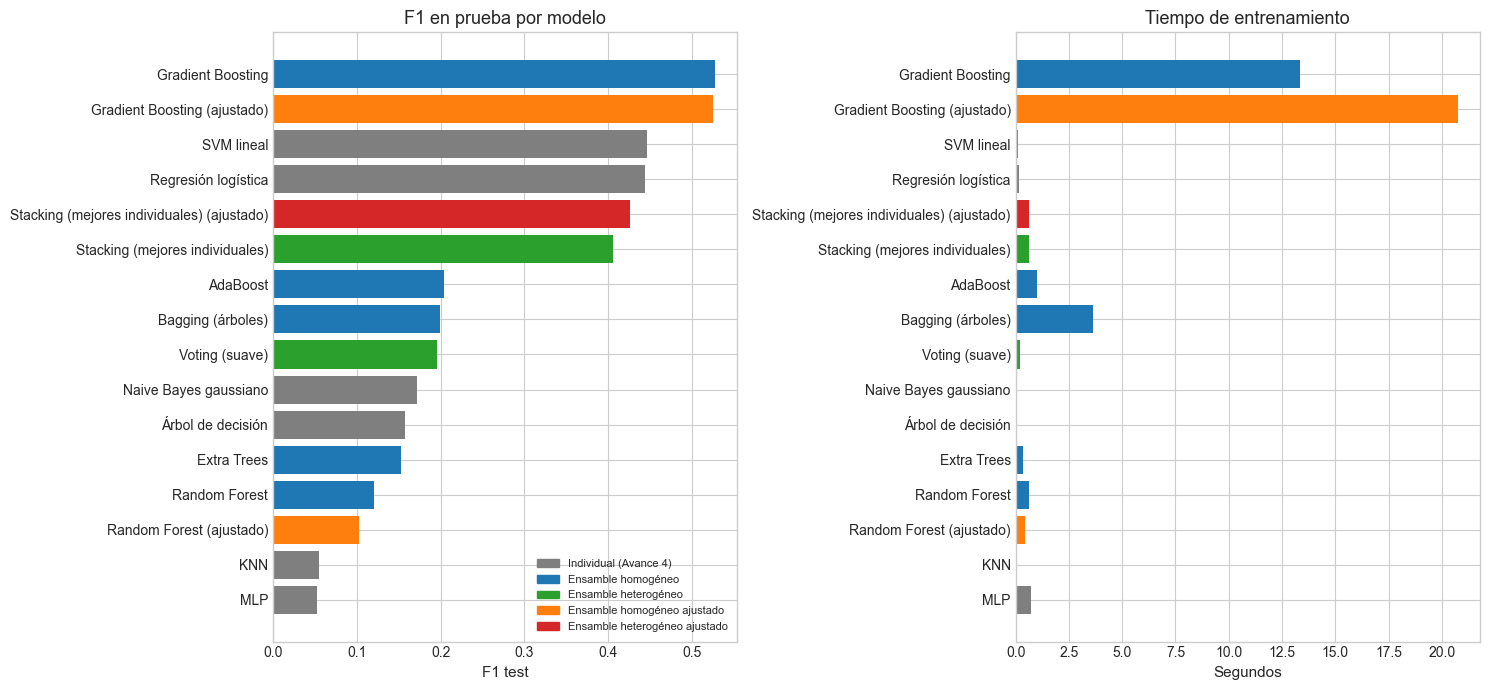

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

color_map = {
    "Individual (Avance 4)": "#7f7f7f",
    "Ensamble homogéneo": "#1f77b4",
    "Ensamble heterogéneo": "#2ca02c",
    "Ensamble homogéneo ajustado": "#ff7f0e",
    "Ensamble heterogéneo ajustado": "#d62728",
}

plot_df = comparison_table.sort_values("f1_test")
colors = [color_map.get(t, "#9467bd") for t in plot_df["tipo"]]

axes[0].barh(plot_df["modelo"], plot_df["f1_test"], color=colors)
axes[0].set_title("F1 en prueba por modelo")
axes[0].set_xlabel("F1 test")

axes[1].barh(plot_df["modelo"], plot_df["training_time_sec"], color=colors)
axes[1].set_title("Tiempo de entrenamiento")
axes[1].set_xlabel("Segundos")

handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in color_map.values()]
axes[0].legend(handles, list(color_map.keys()), loc="lower right", fontsize=8)

plt.tight_layout()
plt.show()

## 7. Modelo seleccionado: Autoencoder LSTM (ensamble temporal no supervisado)

El modelo final del proyecto es el **autoencoder LSTM** ya implementado en esta etapa. Constituye una estrategia de ensamble en sentido amplio: se entrena **un detector independiente por cada par (bomba, sensor)** y la decisión global de monitoreo surge de la combinación de todos esos detectores especializados.

A diferencia de los modelos supervisados, el autoencoder **no depende de la etiqueta proxy**: aprende el patrón normal de vibración y marca como anómalo cualquier comportamiento cuyo error de reconstrucción (MAE) supere un umbral estadístico (`media + 3·desv. estándar`). Esto lo alinea con las necesidades del negocio:

- La etiqueta proxy no representa fallas reales; un modelo no supervisado evita sobreajustarse a una etiqueta artificial.
- Detecta **novedades** (modos de falla nunca vistos), no solo eventos parecidos a los del histórico.
- Funciona por equipo y en tiempo real, y entrega **niveles de severidad** (Normal / Leve / Crítica) útiles para priorizar mantenimiento.

En las secciones siguientes se entrena el autoencoder, se evalúa frente a la etiqueta proxy para situarlo en la tabla comparativa y se generan los gráficos significativos del modelo elegido.

In [12]:
import random
import joblib
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

raw_df = pd.read_csv(RAW_DATA_PATH)
raw_df["timesTamp"] = pd.to_datetime(raw_df["timesTamp"])
raw_df = raw_df.sort_values(["parameterName", "sensorId", "timesTamp"]).reset_index(drop=True)

ae_features = ["RMSVelocityH", "RMSVelocityV", "RMSVelocityA"]
WINDOW_SIZE = 24

print("Senal cruda cargada:", raw_df.shape)
print(raw_df[["parameterName", "sensorId"]].drop_duplicates().shape[0], "pares bomba-sensor")

/opt/anaconda3/envs/proyecto/lib/python3.11/site-packages/requests/__init__.py:92: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


Senal cruda cargada: (52560, 6)
3 pares bomba-sensor


In [13]:
def create_sequences(data, window=WINDOW_SIZE):
    sequences = []
    for i in range(len(data) - window):
        sequences.append(data[i:i + window])
    return np.array(sequences)


def build_lstm_autoencoder(timesteps, n_features):
    inputs = Input(shape=(timesteps, n_features))

    encoded = LSTM(32, activation="tanh", return_sequences=True)(inputs)
    encoded = Dropout(0.2)(encoded)
    encoded = LSTM(16, activation="tanh")(encoded)
    latent = Dense(8, activation="relu")(encoded)

    decoded = RepeatVector(timesteps)(latent)
    decoded = LSTM(16, activation="tanh", return_sequences=True)(decoded)
    decoded = Dropout(0.2)(decoded)
    decoded = LSTM(32, activation="tanh", return_sequences=True)(decoded)
    outputs = Dense(n_features)(decoded)

    model = Model(inputs, outputs)
    model.compile(optimizer="adam", loss="mse")
    return model

In [14]:
resultados = []
ae_training_time = 0.0

for (pump_name, sensor_id), sensor_df in raw_df.groupby(["parameterName", "sensorId"]):
    print(f"\n======================================")
    print(f"Procesando bomba: {pump_name} | Sensor: {sensor_id}")
    print(f"======================================")

    sensor_df = sensor_df.copy()
    sensor_df = sensor_df.dropna(subset=ae_features)
    values = sensor_df[ae_features].values

    if len(values) < 50:
        print(f"No hay suficientes datos para {pump_name}")
        continue

    split_index = int(len(values) * 0.8)
    train_raw = values[:split_index]
    test_raw = values[split_index:]

    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train_raw)
    test_scaled = scaler.transform(test_raw)

    X_seq_train = create_sequences(train_scaled, WINDOW_SIZE)
    X_seq_test = create_sequences(test_scaled, WINDOW_SIZE)

    if len(X_seq_train) == 0 or len(X_seq_test) == 0:
        print(f"No hay suficientes secuencias para {pump_name}")
        continue

    val_size = max(1, int(len(X_seq_train) * 0.1))
    X_val = X_seq_train[-val_size:]
    X_train_final = X_seq_train[:-val_size]

    timesteps = X_seq_train.shape[1]
    n_features = X_seq_train.shape[2]
    model = build_lstm_autoencoder(timesteps, n_features)

    early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
    checkpoint = ModelCheckpoint(f"best_model_{pump_name}_{sensor_id}.keras", monitor="val_loss", save_best_only=True)

    start = perf_counter()
    history = model.fit(
        X_train_final, X_train_final,
        epochs=100,
        batch_size=32,
        validation_data=(X_val, X_val),
        callbacks=[early_stop, checkpoint],
        verbose=0,
    )
    ae_training_time += perf_counter() - start

    train_reconstructions = model.predict(X_seq_train, verbose=0)
    train_mae = np.mean(np.abs(X_seq_train - train_reconstructions), axis=(1, 2))
    threshold = np.mean(train_mae) + 3 * np.std(train_mae)

    reconstructions = model.predict(X_seq_test, verbose=0)
    mae = np.mean(np.abs(X_seq_test - reconstructions), axis=(1, 2))
    anomalies = mae > threshold
    print(f"Threshold: {threshold:.5f} | Anomalias detectadas: {int(np.sum(anomalies))}")

    anomaly_index = np.arange(split_index + WINDOW_SIZE, split_index + WINDOW_SIZE + len(mae))
    df_result = sensor_df.iloc[anomaly_index].copy()
    df_result["parameterName"] = pump_name
    df_result["sensorId"] = sensor_id
    df_result["mae"] = mae
    df_result["anomaly"] = anomalies

    q95 = np.percentile(train_mae, 95)
    q99 = np.percentile(train_mae, 99)

    def classify_severity(error, q95=q95, q99=q99):
        if error < q95:
            return "Normal"
        elif error < q99:
            return "Leve"
        return "Crítica"

    df_result["severity"] = [classify_severity(e) for e in mae]
    resultados.append(df_result)

    joblib.dump(scaler, f"scaler_{pump_name}_{sensor_id}.pkl")
    model.save(f"modelo_lstm_{pump_name}_{sensor_id}.keras")

    del model, X_seq_train, X_seq_test
    tf.keras.backend.clear_session()

print(f"\nTiempo total de entrenamiento del autoencoder: {ae_training_time:.2f} s")


Procesando bomba: Pump_1 | Sensor: 189310001
Threshold: 0.02270 | Anomalias detectadas: 1372

Procesando bomba: Pump_2 | Sensor: 189310002
Threshold: 0.03262 | Anomalias detectadas: 3480

Procesando bomba: Pump_3 | Sensor: 189310003
Threshold: 0.03446 | Anomalias detectadas: 3074

Tiempo total de entrenamiento del autoencoder: 385.70 s


In [15]:
if len(resultados) == 0:
    raise ValueError("No se generaron resultados del autoencoder.")

df_final = pd.concat(resultados, ignore_index=True)
print("Resultados del autoencoder unidos:", df_final.shape)
print("\nDistribucion de severidad:")
print(df_final["severity"].value_counts())

Resultados del autoencoder unidos: (10440, 9)

Distribucion de severidad:
severity
Crítica    7100
Normal     1888
Leve       1452
Name: count, dtype: int64


### Evaluación del autoencoder frente a la etiqueta proxy

Para situar al autoencoder en la misma tabla comparativa, se cruzan sus detecciones con la etiqueta `proxy_anomaly` del baseline (por `timesTamp`, `parameterName` y `sensorId`). Se calculan las mismas métricas usadas para los modelos supervisados. El error de reconstrucción (`mae`) funciona como puntaje continuo de anomalía, lo que permite construir curvas ROC y de precisión-recall.

In [16]:
ae_eval = df_final.merge(
    df[["timesTamp", "parameterName", "sensorId", "proxy_anomaly", "split"]],
    on=["timesTamp", "parameterName", "sensorId"],
    how="inner",
)

ae_eval["y_true"] = ae_eval["proxy_anomaly"].astype(int)
ae_eval["y_pred"] = ae_eval["anomaly"].astype(int)

print(f"Registros del autoencoder con etiqueta proxy disponible: {len(ae_eval):,}")

ae_metrics = classification_metrics(ae_eval["y_true"], ae_eval["y_pred"])
ae_roc_auc = roc_auc_score(ae_eval["y_true"], ae_eval["mae"]) if ae_eval["y_true"].nunique() > 1 else np.nan

autoencoder_row = {
    "modelo": "Autoencoder LSTM (seleccionado)",
    "tipo": "Ensamble temporal no supervisado",
    "f1_test": ae_metrics["f1"],
    "precision_test": ae_metrics["precision"],
    "recall_test": ae_metrics["recall"],
    "balanced_accuracy_test": ae_metrics["balanced_accuracy"],
    "accuracy_test": ae_metrics["accuracy"],
    "alert_rate_test": ae_metrics["alert_rate"],
    "training_time_sec": ae_training_time,
    "f1_gap_train_test": np.nan,
}

print(f"\nF1 test: {ae_metrics['f1']:.4f} | Precision: {ae_metrics['precision']:.4f} | "
      f"Recall: {ae_metrics['recall']:.4f} | ROC AUC: {ae_roc_auc:.4f}")
pd.Series(autoencoder_row)

Registros del autoencoder con etiqueta proxy disponible: 10,440

F1 test: 0.1557 | Precision: 0.0847 | Recall: 0.9711 | ROC AUC: 0.8196


modelo                     Autoencoder LSTM (seleccionado)
tipo                      Ensamble temporal no supervisado
f1_test                                             0.1557
precision_test                                      0.0847
recall_test                                         0.9711
balanced_accuracy_test                              0.6134
accuracy_test                                       0.3032
alert_rate_test                                     0.7592
training_time_sec                                 385.7007
f1_gap_train_test                                      NaN
dtype: object

## 8. Selección del modelo final

Se agrega el autoencoder a la tabla comparativa para tener una visión completa. La elección del modelo final **no se basa únicamente en el F1 frente al proxy**, sino en su alineación con los objetivos del negocio (mantenimiento predictivo real, detección de novedades y operación por equipo).

In [17]:
final_columns = [
    "modelo", "tipo", "f1_test", "precision_test", "recall_test",
    "balanced_accuracy_test", "accuracy_test", "alert_rate_test",
    "training_time_sec", "f1_gap_train_test",
]

final_comparison = (
    pd.concat([comparison_table, pd.DataFrame([autoencoder_row])[final_columns]], ignore_index=True)
    .sort_values([PRIMARY_METRIC, "recall_test"], ascending=False)
    .reset_index(drop=True)
)

print("Tabla comparativa final (todos los modelos):")
final_comparison.round(4)

Tabla comparativa final (todos los modelos):


,modelo,tipo,f1_test,precision_test,recall_test,balanced_accuracy_test,accuracy_test,alert_rate_test,training_time_sec,f1_gap_train_test
0,Gradient Boosting,Ensamble homogéneo,0.5281,0.4786,0.5889,0.7795,0.9531,0.0549,13.3394,0.4719
1,Gradient Boosting (ajustado),Ensamble homogéneo ajustado,0.5249,0.4762,0.5846,0.7773,0.9528,0.0547,20.7494,0.4751
2,SVM lineal,Individual (Avance 4),0.4462,0.7147,0.3243,0.6591,0.9641,0.0202,0.1015,0.1521
3,Regresión logística,Individual (Avance 4),0.4439,0.4677,0.4225,0.7000,0.9528,0.0403,0.1542,-0.0273
4,Stacking (mejores individuales) (ajustado),Ensamble heterogéneo ajustado,0.4264,0.4981,0.3727,0.6776,0.9553,0.0334,0.6077,0.0312
5,Stacking (mejores individuales),Ensamble heterogéneo,0.4062,0.5600,0.3186,0.6535,0.9585,0.0254,0.6169,0.1048
6,AdaBoost,Ensamble homogéneo,0.2041,0.5028,0.1280,0.5611,0.9555,0.0114,1.0033,0.4501
7,Bagging (árboles),Ensamble homogéneo,0.1993,0.6385,0.1181,0.5575,0.9577,0.0082,3.6366,0.5376
8,Voting (suave),Ensamble heterogéneo,0.1962,0.4728,0.1238,0.5587,0.9548,0.0117,0.2131,0.5038
9,Naive Bayes gaussiano,Individual (Avance 4),0.1723,0.1445,0.2134,0.5772,0.9086,0.0658,0.0123,-0.0914


In [18]:
final_model_name = "Autoencoder LSTM (seleccionado)"
best_supervised = comparison_table.iloc[0]

print(f"Modelo final seleccionado: {final_model_name}")
print("\nJustificacion alineada al negocio:")
print("- No requiere la etiqueta proxy (artificial); aprende el comportamiento normal de cada equipo.")
print("- Detecta novedades / modos de falla no vistos, no solo eventos parecidos al historico.")
print("- Opera por bomba-sensor y entrega niveles de severidad para priorizar mantenimiento.")
print("\nReferencia: mejor modelo supervisado por F1 frente al proxy:")
print(f"  {best_supervised['modelo']} -> F1 test = {best_supervised['f1_test']:.4f}")
print(f"Autoencoder -> F1 test (vs proxy) = {autoencoder_row['f1_test']:.4f} | ROC AUC = {ae_roc_auc:.4f}")

Modelo final seleccionado: Autoencoder LSTM (seleccionado)

Justificacion alineada al negocio:
- No requiere la etiqueta proxy (artificial); aprende el comportamiento normal de cada equipo.
- Detecta novedades / modos de falla no vistos, no solo eventos parecidos al historico.
- Opera por bomba-sensor y entrega niveles de severidad para priorizar mantenimiento.

Referencia: mejor modelo supervisado por F1 frente al proxy:
  Gradient Boosting -> F1 test = 0.5281
Autoencoder -> F1 test (vs proxy) = 0.1557 | ROC AUC = 0.8196


## 9. Gráficos significativos del modelo seleccionado

Se generan gráficos del autoencoder LSTM con su interpretación: curva ROC, curva de precisión-recall, matriz de confusión, análisis de residuos (error de reconstrucción) y tendencia con predicción de anomalías sobre la serie temporal de **cada bomba** (Pump_1, Pump_2 y Pump_3).

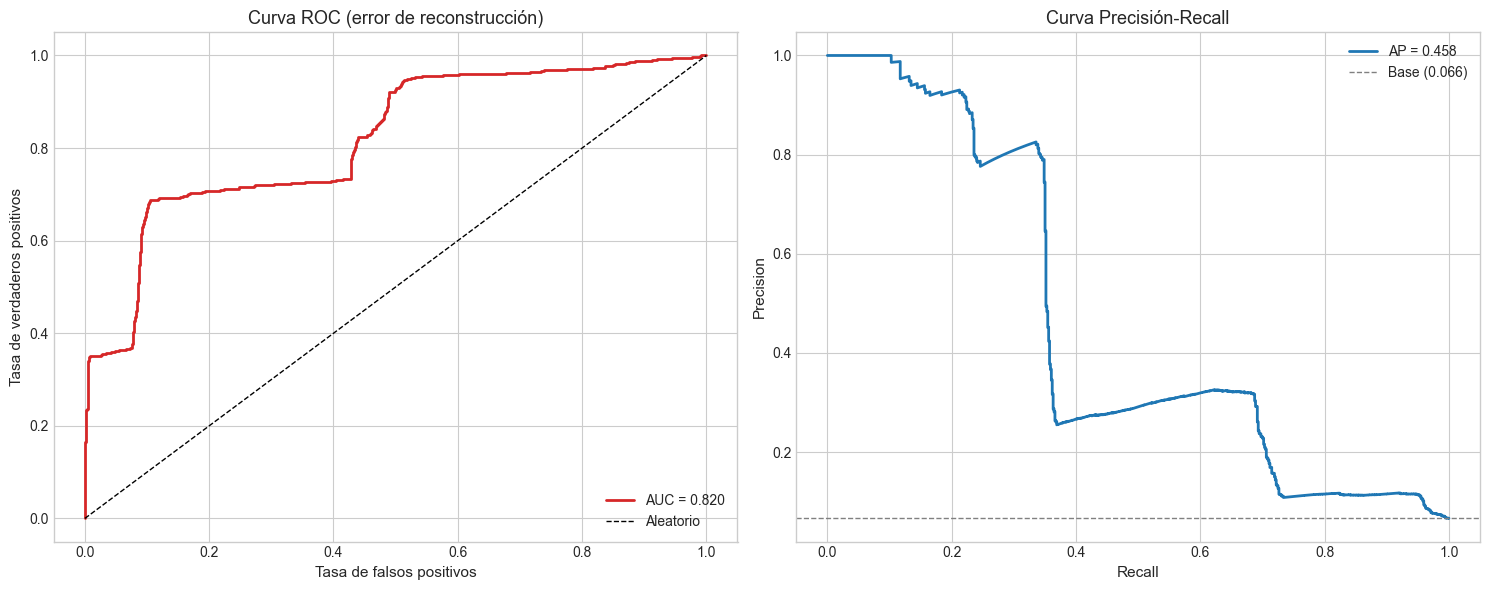

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

fpr, tpr, _ = roc_curve(ae_eval["y_true"], ae_eval["mae"])
axes[0].plot(fpr, tpr, color="#d62728", lw=2, label=f"AUC = {ae_roc_auc:.3f}")
axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="Aleatorio")
axes[0].set_title("Curva ROC (error de reconstrucción)")
axes[0].set_xlabel("Tasa de falsos positivos")
axes[0].set_ylabel("Tasa de verdaderos positivos")
axes[0].legend(loc="lower right")

precision, recall, _ = precision_recall_curve(ae_eval["y_true"], ae_eval["mae"])
ap = average_precision_score(ae_eval["y_true"], ae_eval["mae"])
baseline_rate = ae_eval["y_true"].mean()
axes[1].plot(recall, precision, color="#1f77b4", lw=2, label=f"AP = {ap:.3f}")
axes[1].axhline(baseline_rate, color="gray", ls="--", lw=1, label=f"Base ({baseline_rate:.3f})")
axes[1].set_title("Curva Precisión-Recall")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

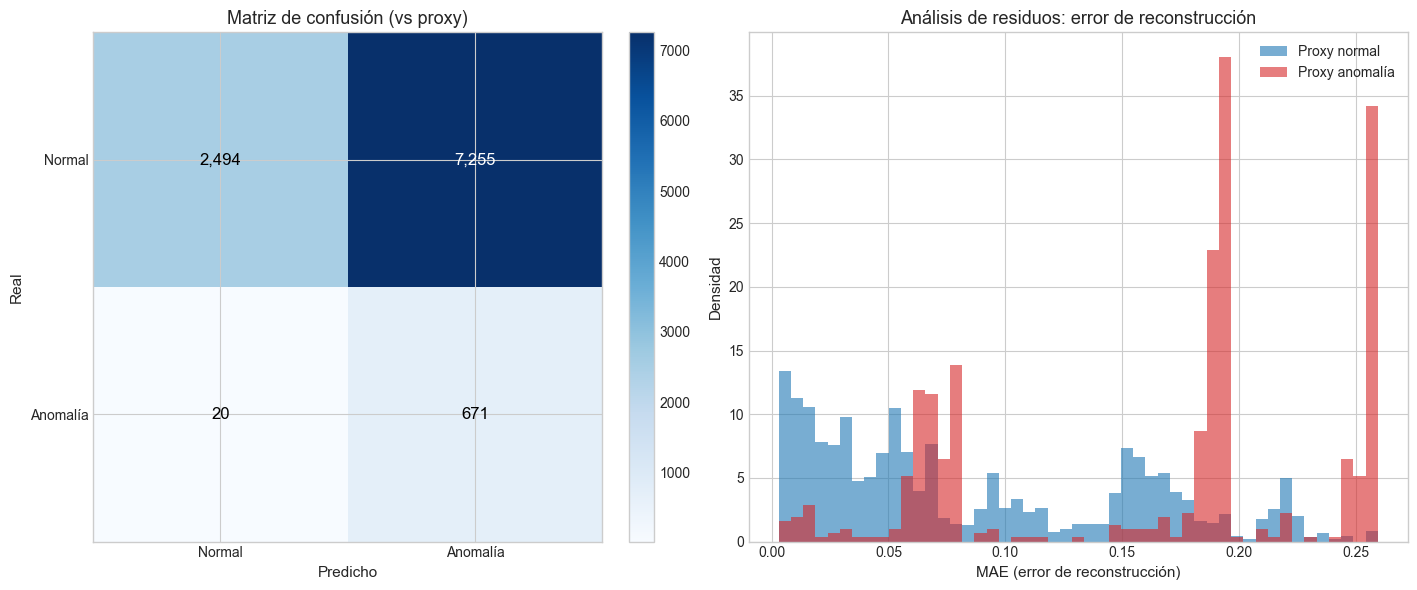

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

cm = confusion_matrix(ae_eval["y_true"], ae_eval["y_pred"], labels=[0, 1])
im = axes[0].imshow(cm, cmap="Blues")
axes[0].set_title("Matriz de confusión (vs proxy)")
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(["Normal", "Anomalía"])
axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(["Normal", "Anomalía"])
axes[0].set_xlabel("Predicho"); axes[0].set_ylabel("Real")
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                     color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=12)
fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

normal_mae = ae_eval.loc[ae_eval["y_true"].eq(0), "mae"]
anom_mae = ae_eval.loc[ae_eval["y_true"].eq(1), "mae"]
bins = np.linspace(ae_eval["mae"].min(), ae_eval["mae"].quantile(0.99), 50)
axes[1].hist(normal_mae, bins=bins, alpha=0.6, label="Proxy normal", color="#1f77b4", density=True)
axes[1].hist(anom_mae, bins=bins, alpha=0.6, label="Proxy anomalía", color="#d62728", density=True)
axes[1].set_title("Análisis de residuos: error de reconstrucción")
axes[1].set_xlabel("MAE (error de reconstrucción)")
axes[1].set_ylabel("Densidad")
axes[1].legend()

plt.tight_layout()
plt.show()

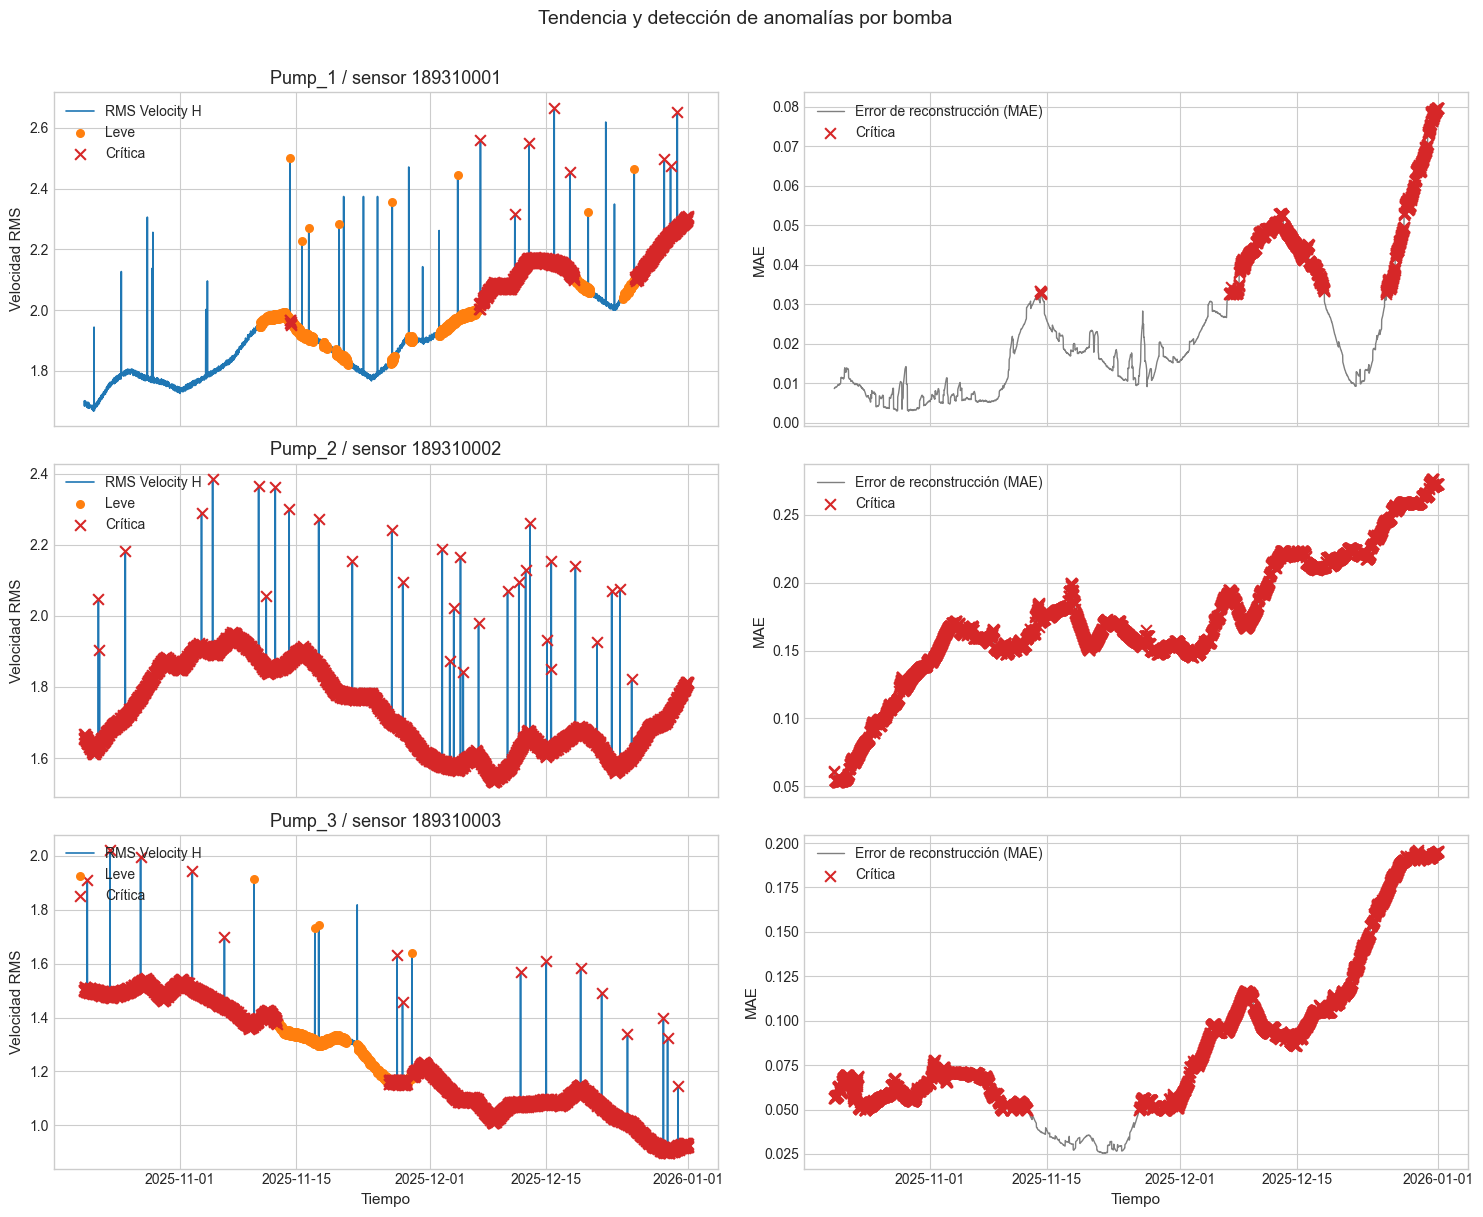

In [21]:
pump_pairs = sorted(df_final.groupby(["parameterName", "sensorId"]).groups.keys())
n_pumps = len(pump_pairs)

fig, axes = plt.subplots(n_pumps, 2, figsize=(15, 4 * n_pumps), sharex="col")
if n_pumps == 1:
    axes = np.array([axes])

for row, (pump_name, sensor_id) in enumerate(pump_pairs):
    serie = df_final[
        df_final["parameterName"].eq(pump_name) & df_final["sensorId"].eq(sensor_id)
    ].sort_values("timesTamp")

    criticas = serie[serie["severity"].eq("Crítica")]
    leves = serie[serie["severity"].eq("Leve")]

    axes[row, 0].plot(serie["timesTamp"], serie["RMSVelocityH"], color="#1f77b4", lw=1.2, label="RMS Velocity H")
    axes[row, 0].scatter(leves["timesTamp"], leves["RMSVelocityH"], color="#ff7f0e", s=30, label="Leve", zorder=3)
    axes[row, 0].scatter(criticas["timesTamp"], criticas["RMSVelocityH"], color="#d62728", marker="x", s=60, label="Crítica", zorder=4)
    axes[row, 0].set_title(f"{pump_name} / sensor {sensor_id}")
    axes[row, 0].set_ylabel("Velocidad RMS")
    axes[row, 0].legend(loc="upper left")

    axes[row, 1].plot(serie["timesTamp"], serie["mae"], color="#7f7f7f", lw=1.0, label="Error de reconstrucción (MAE)")
    axes[row, 1].scatter(criticas["timesTamp"], criticas["mae"], color="#d62728", marker="x", s=60, label="Crítica", zorder=4)
    axes[row, 1].set_ylabel("MAE")
    axes[row, 1].legend(loc="upper left")

axes[-1, 0].set_xlabel("Tiempo")
axes[-1, 1].set_xlabel("Tiempo")
fig.suptitle("Tendencia y detección de anomalías por bomba", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

In [22]:
anomalias = df_final[df_final["anomaly"].eq(True)].copy()
anomalias.to_csv("anomalias_detectadas.csv", index=False)
print(f"Archivo generado: anomalias_detectadas.csv ({len(anomalias):,} anomalias)")
print("Modelos LSTM y scalers guardados por bomba-sensor.")

Archivo generado: anomalias_detectadas.csv (7,926 anomalias)
Modelos LSTM y scalers guardados por bomba-sensor.


## 10. Conclusión

### Comparativa de modelos individuales y de ensamble

La tabla comparativa reúne los seis modelos individuales del Avance 4, siete modelos de ensamble (cinco homogéneos y dos heterogéneos) y sus versiones con hiperparámetros ajustados, todos evaluados sobre la etiqueta proxy con la misma métrica principal (F1 en prueba).

- **Ensambles homogéneos** (Random Forest, Extra Trees, Gradient Boosting, AdaBoost, Bagging) capturan relaciones no lineales que los modelos lineales individuales no modelan, a costa de mayor tiempo de entrenamiento.
- **Ensambles heterogéneos**: el *voting* suave promedia probabilidades de algoritmos diversos, y el *stacking* combina los mejores modelos individuales del Avance 4 con un meta-modelo logístico, cumpliendo el requisito de blending sobre los mejores estimadores previos.
- La **optimización de hiperparámetros** se aplicó a los ensambles más relevantes; cada ajuste se contrastó contra su versión inicial para conservar la mejor configuración y reportar la mejora (o degradación) en el conjunto de prueba.

### Modelo final elegido

El modelo final del proyecto es el **autoencoder LSTM**, alineado con los objetivos del negocio:

1. **Independencia de la etiqueta proxy.** Los modelos supervisados (individuales y ensambles) aprenden a reproducir una etiqueta artificial de eventos extremos, no fallas confirmadas. El autoencoder aprende el comportamiento normal de cada equipo y no hereda ese sesgo.
2. **Detección de novedades.** Al basarse en el error de reconstrucción, marca patrones nunca vistos, lo que es clave para mantenimiento predictivo donde las fallas reales pueden diferir del histórico.
3. **Operación por equipo y severidad.** Entrena un detector por bomba-sensor y clasifica la severidad (Normal / Leve / Crítica), lo que facilita priorizar intervenciones.

La evaluación del autoencoder frente al proxy (curva ROC, precisión-recall y matriz de confusión) confirma que su error de reconstrucción separa de forma razonable los eventos extremos, aunque su F1 directo no es comparable con el de los modelos supervisados porque optimiza un objetivo distinto (reconstrucción, no clasificación de la etiqueta).

### Limitaciones y próximos pasos

1. La etiqueta proxy y el fuerte desbalance temporal impiden afirmar que cualquiera de los modelos detecta fallas reales; los resultados son una comparación técnica.
2. Próximos pasos: sustituir `proxy_anomaly` por registros reales de mantenimiento, calibrar umbrales por equipo, e incorporar métricas de costo asimétrico (penalizar más los falsos negativos) alineadas al impacto operativo real.